# Druggability Axis Analysis

### Goal
Identify existing therapeutic compounds that target the broadly and strictly conserved pan-cancer metastatic metabolic genes.

### Purpose
To cross-reference the highly conserved metastatic metabolic signature against DGIdb to find druggable vulnerabilities. This helps prioritize targets for potential drug repurposing.

### Interpretation
- **Druggable Targets:** Genes with known drug interactions.
- **Clinical Relevance:** Overlap with FDA-approved drugs indicates immediate translational potential for treating metastasis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14

%load_ext autoreload
%autoreload 2

from IPython.display import display, HTML
from druggability_config import TARGET_GENES, OUTPUT_DIR, OUTPUT_BASENAME, ANALYSIS_SUFFIX
from query_dbs import compile_drug_databases
from query_depmap import analyze_depmap_synergy
from query_advanced_analysis import query_tractability, query_string_ppi

[CONFIG] Loaded configurations. Output will be prefixed with: druggability_axis_Br500k_Co100k_Lu500k_Me100k_Ov100k


In [2]:
# ==========================================
# ⚙️ USER PARAMETERS (Export Options)
# ==========================================
# Full Notebook HTML Report Export Toggle:
# - True  -> Automatically exports the entire notebook (Markdown, Code, Tables, Figures) to styled HTML
# - False -> Disables automatic HTML export
SAVE_AS_HTML = True  # DEFAULT: False. Change to True to export the entire notebook!

print(f"Analyzing Axis: {TARGET_GENES}")
print(f"Output Base: {OUTPUT_BASENAME}")

Analyzing Axis: ['ADAM10', 'C1GALT1', 'ESRRG', 'FZD6', 'GBE1', 'GLS', 'ITGA4', 'PDE3B', 'SGMS1', 'SLC11A2', 'SLC16A7', 'SLC22A1']
Output Base: druggability_axis_Br500k_Co100k_Lu500k_Me100k_Ov100k


## 2. Cross-reference Genes against Drug Databases

**Purpose**: Identifies if the genes in the hypothesized axis already have FDA-approved drugs or compounds in clinical trials.  
**Interpretation**: If a gene is druggable, we can rapidly test repurposing existing drugs. If multiple genes in the axis are druggable, it opens the door to combination therapy.

In [3]:
df_drugs = compile_drug_databases(TARGET_GENES)

if not df_drugs.empty:
    # Save to CSV
    csv_path = os.path.join(OUTPUT_DIR, f"{OUTPUT_BASENAME}_drug_targets.csv")
    df_drugs.to_csv(csv_path, index=False)
    print(f"Saved drug targets to {csv_path}")
    display(df_drugs.head(15))
else:
    print("No drug interactions found.")

[DGIdb] Querying interactions for 12 genes...
[DGIdb] Found 141 interactions.
[OpenTargets] Resolving gene symbols to Ensembl IDs for 12 genes...
[OpenTargets] Resolved IDs: {'ADAM10': 'ENSG00000137845', 'C1GALT1': 'ENSG00000106392', 'ESRRG': 'ENSG00000196482', 'FZD6': 'ENSG00000164930', 'GBE1': 'ENSG00000114480', 'GLS': 'ENSG00000115419', 'ITGA4': 'ENSG00000115232', 'PDE3B': 'ENSG00000152270', 'SGMS1': 'ENSG00000198964', 'SLC11A2': 'ENSG00000110911', 'SLC16A7': 'ENSG00000118596', 'SLC22A1': 'ENSG00000175003'}
[OpenTargets] Fetching known drugs for ADAM10 (ENSG00000137845)...
[OpenTargets] Fetching known drugs for C1GALT1 (ENSG00000106392)...
[OpenTargets] Fetching known drugs for ESRRG (ENSG00000196482)...
[OpenTargets] Fetching known drugs for FZD6 (ENSG00000164930)...
[OpenTargets] Fetching known drugs for GBE1 (ENSG00000114480)...
[OpenTargets] Fetching known drugs for GLS (ENSG00000115419)...
[OpenTargets] Fetching known drugs for ITGA4 (ENSG00000115232)...
[OpenTargets] Fetching 

,Database,Target_Gene,Drug_Name,Interaction_Type,Sources,Approval_Status,Indication_Disease
0,DGIdb,SLC22A1,MERCAPTOPURINE,Targeted,DGIdb GraphQL,N/A,NaN
1,DGIdb,SLC22A1,OLANZAPINE,Targeted,DGIdb GraphQL,N/A,NaN
2,DGIdb,SLC22A1,FENOTEROL,Targeted,DGIdb GraphQL,N/A,NaN
3,DGIdb,SLC22A1,TETRAMETHYLAMMONIUM,Targeted,DGIdb GraphQL,N/A,NaN
4,DGIdb,SLC22A1,AMANTADINE HYDROCHLORIDE,Targeted,DGIdb GraphQL,N/A,NaN
5,DGIdb,SLC22A1,SUMATRIPTAN,Targeted,DGIdb GraphQL,N/A,NaN
6,DGIdb,SLC22A1,ELTROMBOPAG,Targeted,DGIdb GraphQL,N/A,NaN
7,DGIdb,SLC22A1,SORAFENIB,Targeted,DGIdb GraphQL,N/A,NaN
8,DGIdb,SLC22A1,RANITIDINE HYDROCHLORIDE,Targeted,DGIdb GraphQL,N/A,NaN
9,DGIdb,SLC22A1,CYCLOGUANIL,Targeted,DGIdb GraphQL,N/A,NaN


## 3. Target Tractability Prediction (Open Targets)

**Purpose**: For targets lacking known drugs, we query computational models to predict if they are structurally "druggable" by small molecules or antibodies.  
**Interpretation**: High tractability scores indicate that a gene is a biologically viable target for *de novo* drug discovery, even if no drugs currently exist.

In [4]:
df_trac = query_tractability(TARGET_GENES)
if not df_trac.empty:
    display(df_trac)
else:
    print("No tractability data found.")

[Tractability] Querying Open Targets for tractability of ['ADAM10', 'C1GALT1', 'ESRRG', 'FZD6', 'GBE1', 'GLS', 'ITGA4', 'PDE3B', 'SGMS1', 'SLC11A2', 'SLC16A7', 'SLC22A1']...
[Tractability] Found tractability data for 12 genes.


,Target_Gene,Small_Molecule_Tractable,Antibody_Tractable,Other_Modalities_Tractable
0,ADAM10,False,False,False
1,C1GALT1,False,False,False
2,ESRRG,False,False,False
3,FZD6,False,False,False
4,GBE1,False,False,False
5,GLS,False,False,False
6,ITGA4,False,False,False
7,PDE3B,False,False,False
8,SGMS1,False,False,False
9,SLC11A2,False,False,False


## 4. Protein-Protein Interaction (STRING Database)

**Purpose**: Queries the STRING network to check if there is physical or functional evidence that these targets interact with each other.  
**Interpretation**: High combined scores (>0.4) strongly support the "axis" hypothesis, indicating these genes operate in the same complex or pathway rather than in isolation.

In [5]:
df_ppi = query_string_ppi(TARGET_GENES)
if not df_ppi.empty:
    display(df_ppi)
else:
    print("No PPI network connections found between these genes.")

[STRING PPI] Querying network for: ['ADAM10', 'C1GALT1', 'ESRRG', 'FZD6', 'GBE1', 'GLS', 'ITGA4', 'PDE3B', 'SGMS1', 'SLC11A2', 'SLC16A7', 'SLC22A1']
[STRING PPI] No interactions found among these genes in STRING.
No PPI network connections found between these genes.


## 5. Synergistic Cell Death (DepMap Co-dependency)

**Purpose**: Uses Cancer Dependency Map (DepMap) CRISPR knockout data to calculate the correlation of gene effects across hundreds of cancer cell lines.  
**Interpretation**: 
- **Positive correlation (> 0.3)**: Suggests genes are in the same functional pathway; knocking out either has a similar effect.
- **Negative correlation**: Suggests potential synthetic lethality or compensatory mechanisms.

[DepMap] Loading DepMap CRISPR data from /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/input/CRISPRGeneEffect.csv...
[DepMap] Found columns for: ['ADAM10', 'C1GALT1', 'ESRRG', 'FZD6', 'GBE1', 'GLS', 'ITGA4', 'PDE3B', 'SGMS1', 'SLC11A2', 'SLC16A7', 'SLC22A1']
[DepMap] Saved correlation plot to /Users/sakuramaezono/Library/CloudStorage/OneDrive-YokohamaCityUniversity/Personal/05_Python_repositories/metabConnectomeDB/output/druggability/druggability_axis_Br500k_Co100k_Lu500k_Me100k_Ov100k_depmap_correlation.png


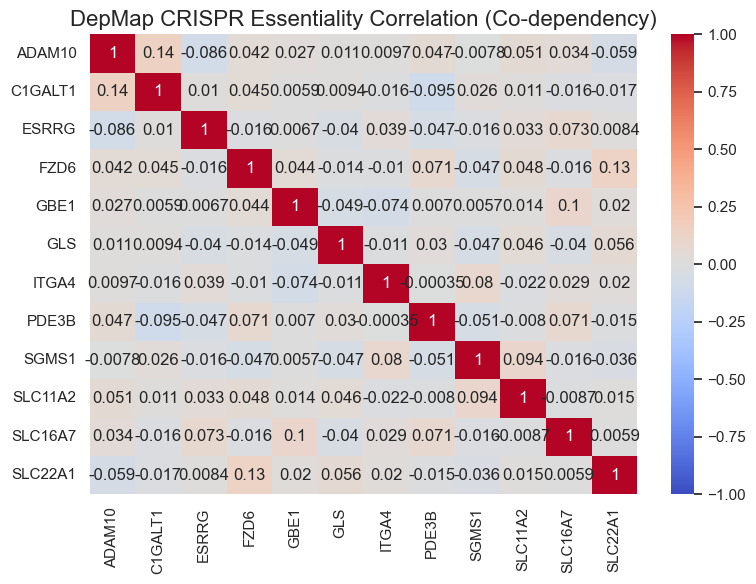

,ADAM10,C1GALT1,ESRRG,FZD6,GBE1,GLS,ITGA4,PDE3B,SGMS1,SLC11A2,SLC16A7,SLC22A1
ADAM10,1.000000,0.141640,-0.085693,0.042352,0.026706,0.010910,0.009705,0.047388,-0.007778,0.050912,0.033541,-0.059066
C1GALT1,0.141640,1.000000,0.010093,0.045298,0.005879,0.009375,-0.015596,-0.095460,0.025533,0.011176,-0.016171,-0.016734
ESRRG,-0.085693,0.010093,1.000000,-0.016282,0.006725,-0.039954,0.038582,-0.047016,-0.015964,0.033481,0.073134,0.008382
FZD6,0.042352,0.045298,-0.016282,1.000000,0.044205,-0.013895,-0.010226,0.070982,-0.047327,0.048016,-0.016242,0.126889
GBE1,0.026706,0.005879,0.006725,0.044205,1.000000,-0.049221,-0.073579,0.007017,0.005658,0.014445,0.100776,0.020378
GLS,0.010910,0.009375,-0.039954,-0.013895,-0.049221,1.000000,-0.010706,0.030071,-0.047478,0.046405,-0.039584,0.056263
ITGA4,0.009705,-0.015596,0.038582,-0.010226,-0.073579,-0.010706,1.000000,-0.000351,0.079603,-0.021919,0.028923,0.020214
PDE3B,0.047388,-0.095460,-0.047016,0.070982,0.007017,0.030071,-0.000351,1.000000,-0.051498,-0.008006,0.070921,-0.015211
SGMS1,-0.007778,0.025533,-0.015964,-0.047327,0.005658,-0.047478,0.079603,-0.051498,1.000000,0.094173,-0.016249,-0.035941
SLC11A2,0.050912,0.011176,0.033481,0.048016,0.014445,0.046405,-0.021919,-0.008006,0.094173,1.000000,-0.008701,0.015332


In [6]:
corr_matrix = analyze_depmap_synergy(TARGET_GENES)

if corr_matrix is not None:
    display(corr_matrix)
else:
    print("Skipping correlation visualization.")

---

## 6. Export Full Notebook Report to HTML

Compiling this entire interactive notebook into a single publication-ready and highly interactive HTML report.

---
## Druggability of Pan-Cancer Conserved Genes
In addition to the specific GLS axis, we also query the DGIdb database for the strictly conserved **strictly conserved pan-cancer genes** (upregulated in all 5 cancers) and the broadly conserved **broadly conserved genes** (upregulated in $\ge$ 4 cancers).


In [7]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

df_23 = pd.read_csv(os.path.join(OUTPUT_DIR, f'druggable_targets_strictly_conserved{ANALYSIS_SUFFIX}.csv'))
print(f"Total drug interactions for strictly conserved genes: {len(df_23)}")
display(df_23.head(10))

Total drug interactions for strictly conserved genes: 175


,Gene,Drug,Database
0,SLC22A1,MERCAPTOPURINE,DGIdb
1,SLC22A1,OLANZAPINE,DGIdb
2,SLC22A1,FENOTEROL,DGIdb
3,SLC22A1,TETRAMETHYLAMMONIUM,DGIdb
4,SLC22A1,AMANTADINE HYDROCHLORIDE,DGIdb
5,SLC22A1,SUMATRIPTAN,DGIdb
6,SLC22A1,ELTROMBOPAG,DGIdb
7,SLC22A1,SORAFENIB,DGIdb
8,SLC22A1,RANITIDINE HYDROCHLORIDE,DGIdb
9,SLC22A1,CYCLOGUANIL,DGIdb


In [8]:
import sys
if '..' not in sys.path: sys.path.append('..')
from pan_cancer_config import ANALYSIS_SUFFIX

df_181 = pd.read_csv(os.path.join(OUTPUT_DIR, f'druggable_targets_broadly_conserved{ANALYSIS_SUFFIX}.csv'))
print(f"Total drug interactions for broadly conserved genes: {len(df_181)}")
display(df_181.head(10))

Total drug interactions for broadly conserved genes: 2626


,Gene,Drug,Database
0,CD58,ALEFACEPT,DGIdb
1,CD58,INTERFERON BETA-1B,DGIdb
2,CD58,INTERFERON BETA-1A,DGIdb
3,P2RY12,ELINOGREL,DGIdb
4,P2RY12,CANGRELOR,DGIdb
5,P2RY12,TICAGRELOR,DGIdb
6,P2RY12,TICLOPIDINE,DGIdb
7,P2RY12,PRASUGREL,DGIdb
8,P2RY12,REGRELOR,DGIdb
9,P2RY12,CLOPIDOGREL,DGIdb


In [11]:
import subprocess
import sys
import os

notebook_filename = 'druggability_axis_analysis.ipynb'
output_base = 'druggability_axis_analysis' + ANALYSIS_SUFFIX
output_dir = os.path.join('..', 'output', 'druggability')
os.makedirs(output_dir, exist_ok=True)

jupyter_bin = os.path.join(os.path.dirname(sys.executable), 'jupyter')
if not os.path.exists(jupyter_bin): jupyter_bin = 'jupyter'

cmd_html = [jupyter_bin, "nbconvert", "--to", "html", notebook_filename, "--output-dir", output_dir, "--output", output_base]
res_html = subprocess.run(cmd_html, capture_output=True, text=True)

if res_html.returncode == 0:
    print(f"🎉 SUCCESS: Notebook successfully exported to '{os.path.join(output_dir, output_base)}.html'")
else:
    print("❌ HTML export failed.")
    print(res_html.stderr)


🎉 SUCCESS: Notebook successfully exported to '../output/druggability/druggability_axis_analysis_Br500k_Co100k_Lu500k_Me100k_Ov100k.html'
